# Sesión 6 · Modelos de nowcasting: regularización

Actividad práctica · 20 minutos en vivo

En esta actividad se estiman los tres modelos regularizados que
se vieron en la sesión teórica: Ridge, LASSO y Elastic Net. El flujo se repetirá en las sesiones 7 y 8:

1. Partir la muestra en **entrenamiento** y **prueba**
2. **Estimar** el modelo sobre el entrenamiento
3. **Predecir** sobre la prueba
4. **Evaluar** con el RMSE y guardar el resultado

Casi todas las celdas ya están escritas y basta con ejecutarlas. Las que están marcadas con
**TU TURNO** contienen un parámetro que se modifica en vivo para observar qué cambia. Ese es
el objetivo de la sesión: no escribir el modelo desde cero, sino entender qué hace cada
parámetro cuando se mueve.

## Preparación

La celda siguiente carga los datos, los procesa (deflactación, desestacionalización,
tasas de crecimiento), restringe a los quince predictores del ejercicio y arma la
partición de entrenamiento y prueba. Es idéntica en las tres actividades, así que
los resultados de las sesiones 6, 7 y 8 son directamente comparables entre sí.

Ejecutar tal cual, no hay nada que modificar.

In [24]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# =========================================================
# Parametros editables
# =========================================================
data_file = "data_BOL.csv"
meta_file = "meta_BOL.csv"

train_start_date = pd.to_datetime("2017-03-01")
test_start_date = pd.to_datetime("2024-03-01")

target_variable = "RGDP0000"
meta_col = "ticket"
cpi = "MCPI0000"

# Seis predictores con lectura economica clara para el PIB de Barbados.
# Para adaptar el taller a Bolivia basta con cambiar esta lista y el archivo
# de datos.
PREDICTORES = [
    "RCEM0007",   # Produccion de cemento total
    "GGTR0024",   # Google Trends: "impuestos nacionales"
    "XIMP0004",   # Importaciones de bienes de consumo duradero
    "RPES0001",   # Superficie en permisos de construccion
    "RPER0001",   # Numero de permisos de construccion
    "GGTR0010",   # Google Trends: "delivery"
    "GGTR0030",   # Google Trends: "laptop"
    "MBCB0002",   # Billetes y monedas en poder del publico
    "XFRD0014",   # Tipo de cambio BRL/USD
    "RRSU0009",   # Residuos solidos recolectados, Trinidad
    "XUSA0001",   # Exportaciones de EE.UU. a Bolivia
    "GGTR0039",   # Google Trends: "toyota"
    "RRSU0007",   # Residuos solidos recolectados, Tarija
    "XEXP0184",   # Exportaciones a Japon
    "XIMP0044",   # Importaciones de Ecuador
]

ETIQUETAS = {
    "RCEM0007": "Produccion de cemento",
    "GGTR0024": "Google Trends: impuestos nacionales",
    "XIMP0004": "Import. consumo duradero",
    "RPES0001": "Superficie permisos construccion",
    "RPER0001": "Permisos de construccion",
    "GGTR0010": "Google Trends: delivery",
    "GGTR0030": "Google Trends: laptop",
    "MBCB0002": "Billetes y monedas en poder del publico",
    "XFRD0014": "Tipo de cambio BRL/USD",
    "RRSU0009": "Residuos solidos Trinidad",
    "XUSA0001": "Export. de EE.UU. a Bolivia",
    "GGTR0039": "Google Trends: toyota",
    "RRSU0007": "Residuos solidos Tarija",
    "XEXP0184": "Export. a Japon",
    "XIMP0044": "Import. de Ecuador",
}

# Carpetas relativas, iguales a las del pipeline del taller
d = os.getcwd() + "/"
PATH_DATA = os.path.join(d, "..", "data")
PATH_OUTPUT = os.path.join(d, "..", "output")
os.makedirs(PATH_OUTPUT, exist_ok=True)

# Archivo donde se acumulan los RMSE de las tres sesiones
RESULTADOS_FILE = os.path.join(PATH_OUTPUT, "resultados_taller.csv")

# =========================================================
# Carga y procesamiento
# =========================================================
data = pd.read_csv(
    os.path.join(PATH_DATA, data_file), parse_dates=["date"], index_col="date"
)
metadata = pd.read_csv(os.path.join(PATH_DATA, meta_file))
test_end_date = data[target_variable].dropna().index.max()

# Deflactacion por IPC (base: promedio de 2017)
base = data[cpi][data.index.year == 2017].mean()
nominal = metadata.loc[metadata["nominal"] == 1][meta_col].values
for column in data.columns:
    if column in nominal:
        data[column] = data[column] / data[cpi] * base
data.drop(columns=[cpi], inplace=True)
data = data.drop(columns=[c for c in data.columns if "RGDP" in c and c != target_variable])

# Desestacionalizacion
quarterly = metadata.loc[metadata["freq"].str.lower().str.contains("q")][meta_col].values
already_sa = metadata.loc[metadata["sa"] == 1][meta_col].values
data = data.loc[:, data.notna().sum() >= 24]
for column in data.columns:
    if column in already_sa:
        continue
    serie = data[column].dropna()
    periodo = 4 if column in quarterly else 12
    decomp = seasonal_decompose(serie, model="additive", extrapolate_trend="freq", period=periodo)
    data[column] = data[column] - decomp.seasonal

# Tasas de crecimiento
for column in data.columns:
    if column in quarterly:
        no_nan = data[column].dropna()
        var = no_nan.pct_change(periods=1, fill_method=None) * 100
        res = pd.Series(np.nan, index=data.index)
        res.loc[var.index] = var
        data[column] = res
    else:
        era_nan = data[column].isna()
        var = data[column].pct_change(periods=1, fill_method=None) * 100
        prev_nan = data[column].shift(1).isna()
        var[prev_nan | era_nan] = np.nan
        data[column] = var
data.replace([np.inf, -np.inf], np.nan, inplace=True)

for column in [c for c in data.columns if c not in quarterly]:
    sub = data[data.index <= test_start_date][column]
    if sub.isna().sum() / len(sub) > 0.75:
        data.drop(column, axis=1, inplace=True)

data = data[~(data.index < train_start_date)]
data = data.dropna(how="all", axis=0)

metadata["months_lag"] = pd.to_numeric(metadata["months_lag"], errors="coerce").fillna(1).astype(int)
tickets_ok = metadata[metadata.months_lag <= 5][meta_col].tolist()
data = data[[c for c in data.columns if c in tickets_ok or "RGDP" in c]]

# =========================================================
# Restriccion a los quince predictores y agregacion trimestral
# =========================================================
columnas = [target_variable] + [c for c in PREDICTORES if c in data.columns]
faltantes = [c for c in PREDICTORES if c not in data.columns]
if faltantes:
    print(f"Aviso: no estan en la base y se omiten -> {faltantes}")
data = data[columnas]

agg_map = metadata.set_index(meta_col)["agg_method"].to_dict()
agg_funcs = {
    col: (agg_map[col] if agg_map.get(col) in ["mean", "last", "sum"] else "mean")
    for col in data.columns
}
data = data.resample("QE").agg(agg_funcs)
data = data[data.index > "2017-01-01"]
data = data[data.index < "2026-01-01"]
data = data.dropna(how="any", axis=0)

train = data[data.index < test_start_date]
test = data[data.index >= test_start_date]

X_train = train.drop(target_variable, axis=1)
y_train = train[target_variable]
X_test = test.drop(target_variable, axis=1)
y_obs = test[target_variable]

predictores = list(X_train.columns)
etiquetas = [ETIQUETAS.get(c, c) for c in predictores]


Las funciones de apoyo de abajo (`rmse`, `tabla_comparativa`, `guardar_resultado`,
`tabla_resultados`, `grafico_observado_predicho`, `resumen_datos`) son las mismas en las
tres sesiones. Ejecutar y seguir.

In [25]:
def rmse(observado, predicho):
    '''Raiz del error cuadratico medio.'''
    return float(np.sqrt(np.mean((np.asarray(observado) - np.asarray(predicho)) ** 2)))


def tabla_comparativa(predicho, nombre="Predicho"):
    '''Tabla de observado contra predicho con el error en puntos porcentuales.'''
    t = pd.DataFrame({"Observado": y_obs, nombre: np.asarray(predicho)}, index=y_obs.index)
    t["Error (pp)"] = t[nombre] - t["Observado"]
    return t


def guardar_resultado(modelo, valor_rmse, sesion, notas=""):
    '''Anade o actualiza una fila en la tabla de resultados del taller.'''
    fila = pd.DataFrame([{
        "modelo": modelo,
        "rmse": round(float(valor_rmse), 4),
        "sesion": sesion,
        "notas": notas,
        "actualizado": datetime.now().strftime("%Y-%m-%d %H:%M"),
    }])
    if os.path.exists(RESULTADOS_FILE):
        prev = pd.read_csv(RESULTADOS_FILE)
        prev = prev[prev["modelo"] != modelo]
        fila = pd.concat([prev, fila], ignore_index=True)
    fila.to_csv(RESULTADOS_FILE, index=False)
    return fila.sort_values("rmse").reset_index(drop=True)


def tabla_resultados():
    '''Devuelve todo lo acumulado hasta ahora, ordenado de mejor a peor.'''
    if not os.path.exists(RESULTADOS_FILE):
        print("Todavia no hay resultados guardados de sesiones anteriores.")
        return pd.DataFrame(columns=["modelo", "rmse", "sesion", "notas"])
    return pd.read_csv(RESULTADOS_FILE).sort_values("rmse").reset_index(drop=True)


def grafico_observado_predicho(predicho, nombre, color="#C0392B", ax=None):
    '''Serie observada contra la predicha en la muestra de prueba.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    ax.plot(y_obs.index, y_obs.values, "o-", color="#2C3E50", lw=2, label="Observado")
    ax.plot(y_obs.index, np.asarray(predicho), "s--", color=color, lw=2, label=nombre)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel("Crecimiento del PIB (%)")
    ax.set_title(f"Observado contra predicho · {nombre}")
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    return ax


def resumen_datos():
    '''Imprime el estado de la base para verificar que todo cargo bien.'''
    print("=" * 62)
    print("BASE LISTA PARA LA ACTIVIDAD")
    print("=" * 62)
    print(f"Variable objetivo : {target_variable}")
    print(f"Predictores       : {len(predictores)} -> {', '.join(predictores)}")
    print(f"Entrenamiento     : {train.index.min():%Y-%m} a {train.index.max():%Y-%m} "
          f"({len(train)} trimestres)")
    print(f"Prueba            : {test.index.min():%Y-%m} a {test.index.max():%Y-%m} "
          f"({len(test)} trimestres)")
    print("=" * 62)
    return data.tail(5)

In [26]:
resumen_datos()

BASE LISTA PARA LA ACTIVIDAD
Variable objetivo : RGDP0000
Predictores       : 15 -> RCEM0007, GGTR0024, XIMP0004, RPES0001, RPER0001, GGTR0010, GGTR0030, MBCB0002, XFRD0014, RRSU0009, XUSA0001, GGTR0039, RRSU0007, XEXP0184, XIMP0044
Entrenamiento     : 2018-03 a 2023-12 (24 trimestres)
Prueba            : 2024-03 a 2025-12 (8 trimestres)


,RGDP0000,RCEM0007,GGTR0024,XIMP0004,RPES0001,RPER0001,GGTR0010,GGTR0030,MBCB0002,XFRD0014,RRSU0009,XUSA0001,GGTR0039,RRSU0007,XEXP0184,XIMP0044
date,,,,,,,,,,,,,,,,
2024-12-31,-1.796869,24.255262,1.274906,2.151986,10.601334,-0.998774,6.405377,-0.476744,0.820420,3.289575,-9.940634,-32.388920,3.830076,-3.348885,26.636685,8.136632
2025-03-31,-1.573398,-15.612189,-3.826321,-1.960024,17.709496,-7.650847,0.804614,-0.407338,2.106395,-1.716580,-3.714773,55.889930,0.609912,7.112024,-0.905111,33.819886
2025-06-30,4.780676,10.935812,10.082885,-6.225064,47.243170,58.856175,12.496958,-0.099805,-1.524221,-1.047646,12.248516,6.883326,1.775363,7.830539,34.387584,12.539012
2025-09-30,-1.946797,-9.012130,-7.687357,20.054238,16.024566,-42.232160,-0.491450,-1.123689,1.156407,-1.490886,6.539701,16.015076,-2.588310,-1.714156,27.496636,2.841150
2025-12-31,-2.223851,-0.984984,-3.008830,-6.012833,0.597970,-13.210715,29.277048,6.496671,-2.121670,0.563737,8.057551,16.641544,4.757171,-2.206910,-3.248129,-20.048214


## Punto de partida: el OLS

Antes de penalizar nada conviene tener el número contra el cual comparar, un modelo simple de OLS.

In [27]:
from sklearn.linear_model import LinearRegression

ols = LinearRegression().fit(X_train, y_train)
pred_ols = ols.predict(X_test)

rmse_ols = rmse(y_obs, pred_ols)
print(f"RMSE del OLS: {rmse_ols:.4f}")

tabla_comparativa(pred_ols, "OLS")

RMSE del OLS: 3.3728


,Observado,OLS,Error (pp)
date,,,
2024-03-31,-1.627019,1.873719,3.500738
2024-06-30,6.097000,8.571546,2.474546
2024-09-30,-4.062978,-7.261082,-3.198104
2024-12-31,-1.796869,2.420948,4.217817
2025-03-31,-1.573398,4.336997,5.910394
2025-06-30,4.780676,2.412178,-2.368498
2025-09-30,-1.946797,-0.114133,1.832664
2025-12-31,-2.223851,-3.064824,-0.840973


### Diagnóstico completo del OLS

`LinearRegression` de sklearn no imprime nada más que el modelo ajustado, así que para ver
los coeficientes con su error estándar, el estadístico t, el p-valor y el R² se puede usar `statsmodels`. Es el mismo modelo, solo que con el diagnóstico completo que después no
vamos a tener para Ridge, LASSO o los árboles, precisamente porque esos ya no reportan
significancia estadística de esa forma.


In [28]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
ols_sm = sm.OLS(y_train, X_train_const).fit()
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               RGDP0000   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     11.19
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           0.000894
Time:                        15:12:29   Log-Likelihood:                -40.209
No. Observations:                  24   AIC:                             112.4
Df Residuals:                       8   BIC:                             131.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1290      1.002      2.125      0.0

,modelo,rmse,sesion,notas,actualizado
0,Ridge,3.1651,6,alpha=10.0,2026-10-07 14:47
1,Elastic Net,3.3013,6,"alpha=0.1, l1_ratio=0.25",2026-10-07 14:48
2,LASSO,3.3168,6,alpha=0.05,2026-10-07 14:47
3,OLS,3.3728,6,Referencia sin penalizacion,2026-10-07 15:12


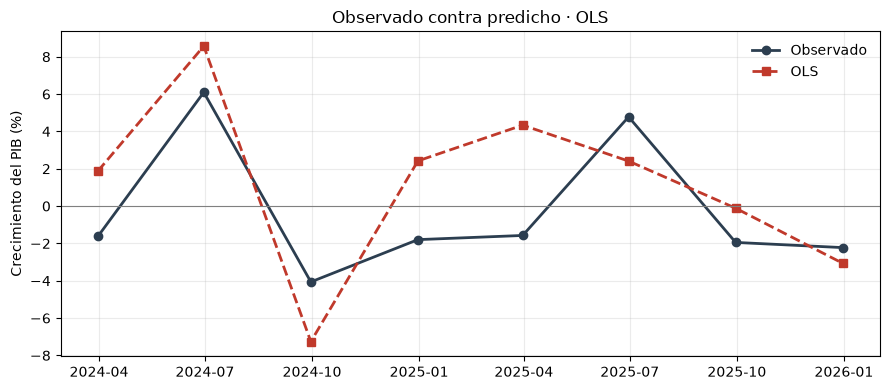

In [29]:
grafico_observado_predicho(pred_ols, "OLS")
guardar_resultado("OLS", rmse_ols, sesion=6, notas="Referencia sin penalizacion")

## Ridge

Ridge añade la penalización L2, que encoge todos los coeficientes hacia cero de forma
proporcional pero sin llevar ninguno exactamente a cero. `RidgeCV` prueba una grilla de
valores del parámetro de penalización y se queda con el que minimiza el error por validación
cruzada.

| Parámetro | Efecto |
|---|---|
| `alphas` | Grilla de penalizaciones a evaluar. Valores grandes encogen más; valores cercanos a cero devuelven el OLS. |

El atributo `.alpha_` del modelo ya estimado indica cuál ganó.

In [30]:
from sklearn.linear_model import RidgeCV
import numpy as np

grilla = [0.0001, 0.001, 0.01, 0.1, 1, 10, 20]

ridge = RidgeCV(alphas=grilla).fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

rmse_ridge = rmse(y_obs, pred_ridge)
print(f"Alpha elegido por validacion cruzada: {ridge.alpha_}")
print(f"RMSE del Ridge: {rmse_ridge:.4f}   (OLS: {rmse_ols:.4f})")
print(f"R2 en prueba: {ridge.score(X_test, y_obs):.3f}")

guardar_resultado("Ridge", rmse_ridge, sesion=6, notas=f"alpha={ridge.alpha_}")

Alpha elegido por validacion cruzada: 10.0
RMSE del Ridge: 3.1651   (OLS: 3.3728)
R2 en prueba: 0.138


,modelo,rmse,sesion,notas,actualizado
0,Ridge,3.1651,6,alpha=10.0,2026-10-07 15:12
1,Elastic Net,3.3013,6,"alpha=0.1, l1_ratio=0.25",2026-10-07 14:48
2,LASSO,3.3168,6,alpha=0.05,2026-10-07 14:47
3,OLS,3.3728,6,Referencia sin penalizacion,2026-10-07 15:12


### Gráfico 1 · La curva de validación cruzada

Este gráfico responde de dónde salió ese alpha. En el eje horizontal va la penalización en
escala logarítmica y en el vertical el error de validación cruzada. La línea vertical marca
el valor que eligió `RidgeCV`.

Lo que se busca ver es la forma de U: por la izquierda hay poca penalización y el modelo se
sobreajusta, por la derecha hay demasiada y el modelo se vuelve tan rígido que deja de
seguir a los datos. El mínimo es el compromiso entre sesgo y varianza del que habla la
teoría, ahora sobre la base del ejercicio y no sobre una figura de libro.

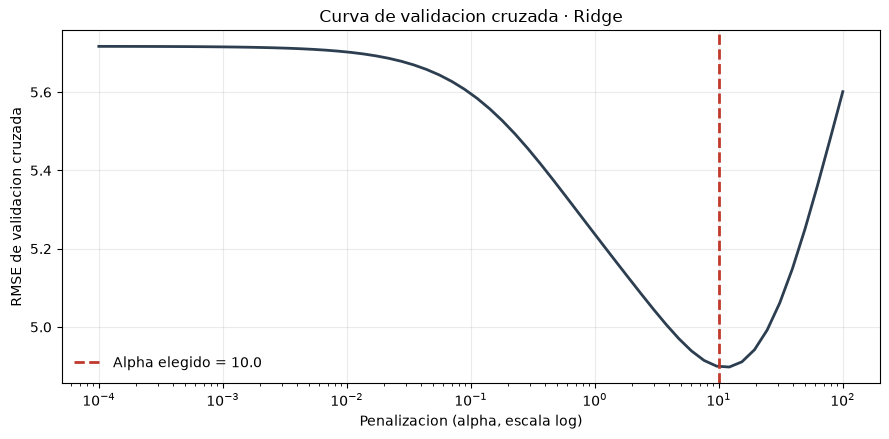

In [31]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

alphas = np.logspace(-4, 2, 60)
cv = KFold(n_splits=5, shuffle=False)

errores = []
for a in alphas:
    puntajes = cross_val_score(
        Ridge(alpha=a), X_train, y_train,
        scoring="neg_root_mean_squared_error", cv=cv
    )
    errores.append(-puntajes.mean())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(alphas, errores, color="#2C3E50", lw=2)
ax.axvline(ridge.alpha_, color="#C0392B", ls="--", lw=2,
           label=f"Alpha elegido = {ridge.alpha_}")
ax.set_xscale("log")
ax.set_xlabel("Penalizacion (alpha, escala log)")
ax.set_ylabel("RMSE de validacion cruzada")
ax.set_title("Curva de validacion cruzada · Ridge")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()

## LASSO

LASSO usa la penalización L1, que a diferencia de Ridge sí lleva coeficientes exactamente a
cero. Esa es la razón por la que se dice que selecciona variables: el modelo resultante deja
fuera predictores enteros en lugar de quedarse con todos encogidos.

| Parámetro | Efecto |
|---|---|
| `alpha` | Fuerza de la penalización L1. Más alto implica más ceros y un modelo más simple. Más bajo se acerca al OLS. |

### Explorando el parámetro

En vez de ir editando `alpha` a mano y corriendo la celda una y otra vez, la celda de abajo
prueba de una sola vez seis valores típicos y arma una tabla con el RMSE y cuántas variables
sobreviven en cada uno. Así se ve el patrón completo sin perder el hilo de qué se probó y
qué no.

In [32]:
from sklearn.linear_model import Lasso

alphas_explorar = [0.001, 0.01, 0.05, 0.1, 0.5, 1]

exploracion = []
for a in alphas_explorar:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    exploracion.append({
        "alpha": a,
        "RMSE": round(rmse(y_obs, m.predict(X_test)), 4),
        "Variables sobrevivientes": int((np.abs(m.coef_) > 1e-10).sum()),
    })

exploracion = pd.DataFrame(exploracion)
exploracion

,alpha,RMSE,Variables sobrevivientes
0,0.001,3.3715,15
1,0.010,3.3605,15
2,0.050,3.3168,15
3,0.100,3.2504,15
4,0.500,2.8948,14
5,1.000,2.4182,12


### TU TURNO: fijar el modelo final

Mirando la tabla de arriba, elegir el `alpha` con mejor RMSE (o el que mejor equilibrio te
parezca entre error y número de variables) y ponerlo aquí. Esta es la versión de LASSO que
queda guardada como resultado oficial de la sesión.

In [33]:
# ============ TU TURNO ============
# Copiar aqui el alpha elegido a partir de la tabla de exploracion de arriba.
alpha_lasso = 0.5
# ==================================

lasso = Lasso(alpha=alpha_lasso, max_iter=10000).fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)
rmse_lasso = rmse(y_obs, pred_lasso)

coefs = pd.DataFrame({
    "Variable": etiquetas,
    "Coeficiente": lasso.coef_.round(4),
    "Sobrevive": np.where(np.abs(lasso.coef_) > 1e-10, "Si", "No")
})

print(f"RMSE del LASSO: {rmse_lasso:.4f}   (OLS: {rmse_ols:.4f})")
print(f"Variables que sobreviven: {(np.abs(lasso.coef_) > 1e-10).sum()} de {len(predictores)}")
coefs

RMSE del LASSO: 2.8948   (OLS: 3.3728)
Variables que sobreviven: 14 de 15


,Variable,Coeficiente,Sobrevive
0,Produccion de cemento,-0.0818,Si
1,Google Trends: impuestos nacionales,-0.2180,Si
2,Import. consumo duradero,0.0420,Si
3,Superficie permisos construccion,-0.0287,Si
4,Permisos de construccion,0.1106,Si
5,Google Trends: delivery,-0.0107,Si
6,Google Trends: laptop,-0.4555,Si
7,Billetes y monedas en poder del publico,0.0000,No
8,Tipo de cambio BRL/USD,-0.0847,Si
9,Residuos solidos Trinidad,-0.1801,Si


In [34]:
guardar_resultado("LASSO", rmse_lasso, sesion=6, notas=f"alpha={alpha_lasso}")

,modelo,rmse,sesion,notas,actualizado
0,LASSO,2.8948,6,alpha=0.5,2026-10-07 15:12
1,Ridge,3.1651,6,alpha=10.0,2026-10-07 15:12
2,Elastic Net,3.3013,6,"alpha=0.1, l1_ratio=0.25",2026-10-07 14:48
3,OLS,3.3728,6,Referencia sin penalizacion,2026-10-07 15:12


### Gráfico 2 · La senda de regularización

Este es el gráfico central de la sesión. Cada línea es un coeficiente y el eje horizontal es
la penalización creciendo de izquierda a derecha. A la izquierda del todo no hay castigo y
los coeficientes valen lo que valdrían en un OLS; a medida que se avanza hacia la derecha la
penalización aprieta.

La diferencia entre los dos paneles es toda la sesión resumida en una imagen. En LASSO las
líneas tocan el eje horizontal y se quedan pegadas: la variable salió del modelo y no vuelve.
En Ridge las líneas se acercan al cero asintóticamente sin tocarlo nunca, porque la
penalización L2 encoge pero no elimina.

La pregunta para el grupo es cuál de las seis series de Barbados es la última en morir en el
panel de LASSO. Es el mismo gráfico que aparece en la parte teórica, con la diferencia de que
allá las series eran simuladas y con el resultado sabido de antemano, y aquí no se sabe cuál
va a sobrevivir.

Con una salvedad importante, dado que no estamos estandarizando: el orden de salida mezcla
dos cosas, cuánto informa cada serie sobre el PIB y cuán volátil es. La última en morir es la
que el modelo considera más difícil de reemplazar, pero también tiene ventaja la que se mueve
más. Conviene mirar el gráfico junto a la tabla de desviaciones típicas del inicio antes de
sacar conclusiones sobre cuál indicador es el más informativo.

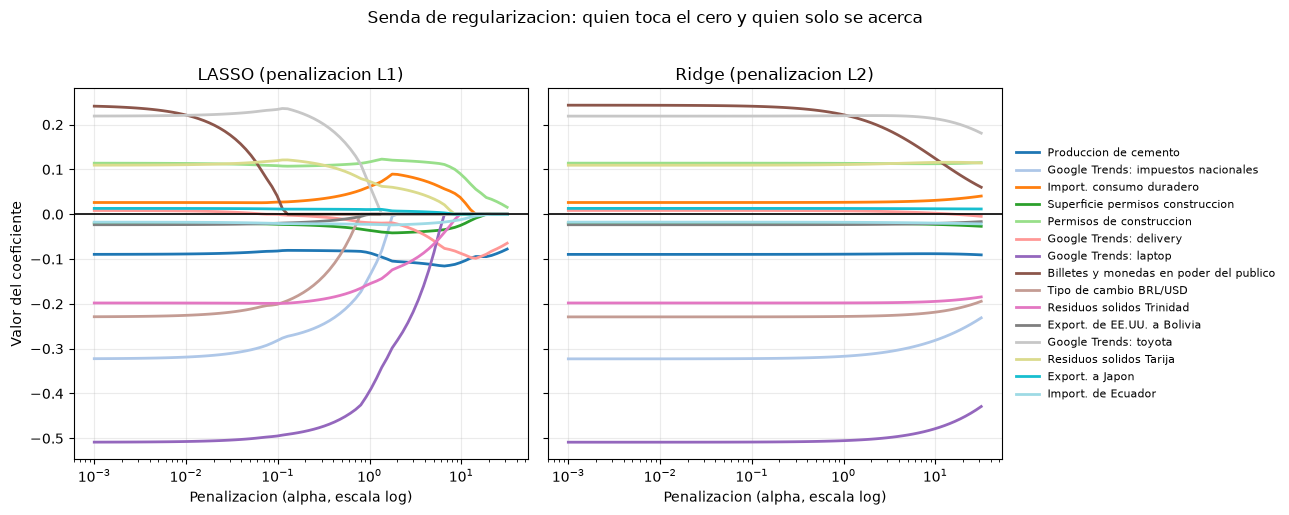

In [35]:
grilla_path = np.logspace(-3, 1.5, 80)

coef_lasso = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_ for a in grilla_path
])
coef_ridge = np.array([
    Ridge(alpha=a).fit(X_train, y_train).coef_ for a in grilla_path
])

colores = plt.cm.tab20(np.linspace(0, 1, len(etiquetas)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for j, nombre in enumerate(etiquetas):
    axes[0].plot(grilla_path, coef_lasso[:, j], lw=2, color=colores[j], label=nombre)
    axes[1].plot(grilla_path, coef_ridge[:, j], lw=2, color=colores[j], label=nombre)

for ax, titulo in zip(axes, ["LASSO (penalizacion L1)", "Ridge (penalizacion L2)"]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=1.2)
    ax.set_xlabel("Penalizacion (alpha, escala log)")
    ax.set_title(titulo)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Valor del coeficiente")
axes[1].legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.suptitle("Senda de regularizacion: quien toca el cero y quien solo se acerca", y=1.02)
plt.tight_layout()

## Elastic Net

Elastic Net combina las dos penalizaciones. La parte L1 selecciona variables y la parte L2
estabiliza la estimación cuando los predictores están correlacionados entre sí, situación en
la que LASSO tiende a quedarse con una de las series correlacionadas y descartar el resto de
forma bastante arbitraria.

Hay una segunda razón, que con seis variables no se alcanza a ver pero pesa mucho en el
pipeline real: cuando p>n, LASSO no puede seleccionar más de n variables por más informativas
que sean las demás. Es un límite matemático del método, no un asunto de calibración. El
término L2 de Elastic Net resuelve esa ambigüedad y le permite usar las p variables, que es
la razón por la que la lámina de comparación lo llama el default razonable para nowcasting.

| Parámetro | Efecto |
|---|---|
| `alpha` | Fuerza total de la penalización. |
| `l1_ratio` | Mezcla entre las dos. Con 1 es LASSO puro, con 0 es Ridge puro. |

### Explorando el parámetro

Igual que con LASSO, se recorre de una vez una grilla de `l1_ratio` con `alpha` fijo y se
tabula cuántas variables sobreviven en cada mezcla.

In [36]:
from sklearn.linear_model import ElasticNet

alpha_enet = 0.1
l1_ratios_explorar = [0.1, 0.25, 0.5, 0.75, 0.9]

exploracion_enet = []
for l1r in l1_ratios_explorar:
    m = ElasticNet(alpha=alpha_enet, l1_ratio=l1r, max_iter=10000).fit(X_train, y_train)
    exploracion_enet.append({
        "l1_ratio": l1r,
        "RMSE": round(rmse(y_obs, m.predict(X_test)), 4),
        "Variables sobrevivientes": int((np.abs(m.coef_) > 1e-10).sum()),
    })

exploracion_enet = pd.DataFrame(exploracion_enet)
exploracion_enet

,l1_ratio,RMSE,Variables sobrevivientes
0,0.10,3.3085,15
1,0.25,3.3013,15
2,0.50,3.2901,15
3,0.75,3.2760,14
4,0.90,3.2589,14


### TU TURNO: fijar el modelo final

Elegir el `l1_ratio` de la tabla de arriba y dejarlo aquí como versión oficial.

In [37]:
# ============ TU TURNO ============
# Copiar aqui el l1_ratio elegido a partir de la tabla de exploracion de arriba.
l1_ratio = 0.25
# ==================================

enet = ElasticNet(alpha=alpha_enet, l1_ratio=l1_ratio, max_iter=10000).fit(X_train, y_train)
pred_enet = enet.predict(X_test)
rmse_enet = rmse(y_obs, pred_enet)

print(f"RMSE del Elastic Net: {rmse_enet:.4f}   (OLS: {rmse_ols:.4f})")
print(f"Variables que sobreviven: {(np.abs(enet.coef_) > 1e-10).sum()} de {len(predictores)}")

guardar_resultado("Elastic Net", rmse_enet, sesion=6,
                  notas=f"alpha={alpha_enet}, l1_ratio={l1_ratio}")

RMSE del Elastic Net: 3.3013   (OLS: 3.3728)
Variables que sobreviven: 15 de 15


,modelo,rmse,sesion,notas,actualizado
0,LASSO,2.8948,6,alpha=0.5,2026-10-07 15:12
1,Ridge,3.1651,6,alpha=10.0,2026-10-07 15:12
2,Elastic Net,3.3013,6,"alpha=0.1, l1_ratio=0.25",2026-10-07 15:12
3,OLS,3.3728,6,Referencia sin penalizacion,2026-10-07 15:12


### Gráfico 3 · Los cuatro modelos sobre las mismas variables

Aquí se ven los coeficientes de los cuatro modelos, uno al lado del otro, para cada una de
las seis series. Las barras ausentes de LASSO y de Elastic Net son las variables que la
penalización eliminó, y el cambio de altura respecto al OLS es cuánto encogió cada modelo a
las que sí conservó.

La comparación válida aquí es vertical, es decir la misma variable entre modelos, porque ahí
sí se está viendo el efecto de la penalización. La comparación horizontal, entre variables
distintas, no dice cuál importa más: sin estandarizar, la altura de la barra depende también
de la escala de cada serie.

,OLS,Ridge,LASSO,Elastic Net
Produccion de cemento,-0.0896,-0.0882,-0.0818,-0.0869
Google Trends: impuestos nacionales,-0.3227,-0.2813,-0.2180,-0.3040
Import. consumo duradero,0.0262,0.0310,0.0420,0.0269
Superficie permisos construccion,-0.0198,-0.0227,-0.0287,-0.0210
Permisos de construccion,0.1140,0.1127,0.1106,0.1119
Google Trends: delivery,0.0084,0.0023,-0.0107,0.0042
Google Trends: laptop,-0.5087,-0.4784,-0.4555,-0.4989
Billetes y monedas en poder del publico,0.2433,0.1242,0.0000,0.1605
Tipo de cambio BRL/USD,-0.2291,-0.2185,-0.0847,-0.2190
Residuos solidos Trinidad,-0.1980,-0.1945,-0.1801,-0.1978


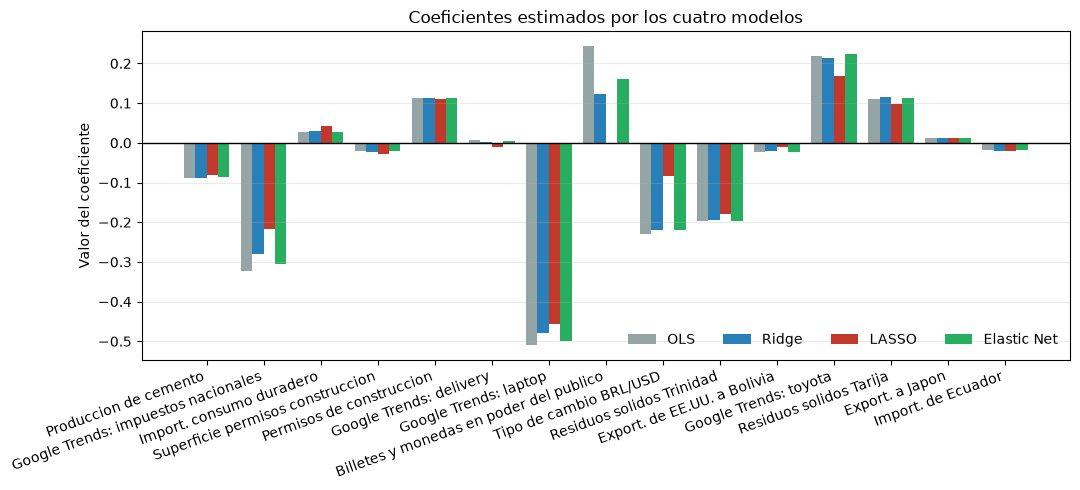

In [38]:
comparacion = pd.DataFrame({
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "LASSO": lasso.coef_,
    "Elastic Net": enet.coef_,
}, index=etiquetas)

fig, ax = plt.subplots(figsize=(11, 5))
ancho = 0.2
x = np.arange(len(etiquetas))
paleta = ["#95A5A6", "#2980B9", "#C0392B", "#27AE60"]

for i, (modelo, color) in enumerate(zip(comparacion.columns, paleta)):
    ax.bar(x + i * ancho - 1.5 * ancho, comparacion[modelo], ancho,
           label=modelo, color=color)

ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=20, ha="right")
ax.set_ylabel("Valor del coeficiente")
ax.set_title("Coeficientes estimados por los cuatro modelos")
ax.legend(frameon=False, ncol=4)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()

comparacion.round(4)

## Cierre: tabla de resultados

Todo lo estimado queda guardado en `resultados_taller.csv`, dentro de la carpeta de salida.
Ese archivo se va llenando a lo largo de las tres sesiones, así que en la sesión 8 se podrá
comparar el LSTM contra estos cuatro modelos sin volver a estimarlos.

In [39]:
tabla_resultados()

,modelo,rmse,sesion,notas,actualizado
0,LASSO,2.8948,6,alpha=0.5,2026-10-07 15:12
1,Ridge,3.1651,6,alpha=10.0,2026-10-07 15:12
2,Elastic Net,3.3013,6,"alpha=0.1, l1_ratio=0.25",2026-10-07 15:12
3,OLS,3.3728,6,Referencia sin penalizacion,2026-10-07 15:12
